In [57]:
!pip install ultralytics
from ultralytics import YOLO
import cv2
import pandas as pd
from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import cv2
import json
import matplotlib.patches as patches
from scipy.spatial import distance
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

In [58]:
model_person = YOLO("yolov8n.pt")
image_data = Image.open('L_nXP3v_DA8_250.png')
results = model_person.predict(image_data,classes=[0],conf=0.2,show=True)


0: 384x640 11 persons, 218.0ms
Speed: 4.4ms preprocess, 218.0ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


In [59]:
[list(image_data.size)[0]//2,list(image_data.size)[1]//2]

[640, 360]

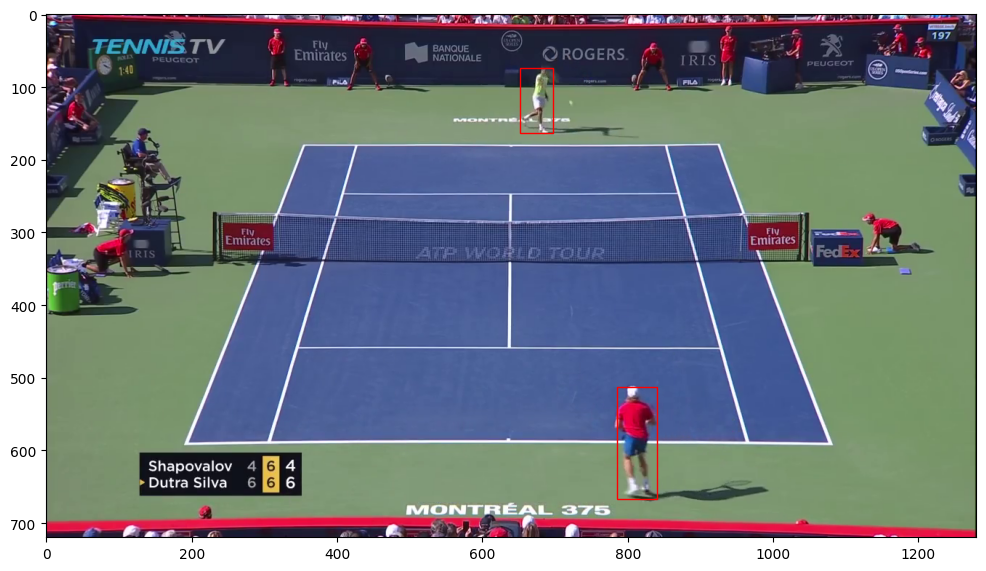

In [60]:
fig, ax = plt.subplots(1, figsize=(12, 8))
image_plot = ax.imshow(image_data)
boxes = []
distance_centre = pd.DataFrame(columns=['distance'])
image_centre = [list(image_data.size)[0]//2,list(image_data.size)[1]//2]
for result in results:
  for number,box in enumerate(result.boxes.xyxy.tolist()):
    distance_centre.loc[number,'distance'] = distance.euclidean(image_centre,np.array(box[:2]))
for result in results:
    for number,box in enumerate(result.boxes.xywh.tolist()):
      if number in distance_centre.sort_values(by='distance',ascending=True)[:2].index:
        ax.add_patch(patches.Rectangle((box[0] - box[2]/2, box[1] - box[3]/2), box[2], box[3], linewidth=1, edgecolor='r', facecolor='none'))
        boxes.append(box)
plt.show()

In [61]:
player_image_1 = image_data.crop((boxes[0][0]-boxes[0][2]/2,boxes[0][1]-boxes[0][3]/2,boxes[0][0]+boxes[0][2]/2,boxes[0][1]+boxes[0][3]/2))
player_image_2 = image_data.crop((boxes[1][0]-boxes[1][2]/2,boxes[1][1]-boxes[1][3]/2,boxes[1][0]+boxes[1][2]/2,boxes[1][1]+boxes[1][3]/2))

In [62]:
boxes

[[812.57080078125, 589.3475341796875, 55.585205078125, 154.42529296875],
 [674.1138916015625, 117.89620971679688, 45.083984375, 89.93853759765625]]

In [63]:
kmeans = KMeans(n_clusters=10,random_state=10)
kmeans.fit(np.array(player_image_1).reshape((-1, 3)))
colors_1 = kmeans.cluster_centers_
kmeans.fit(np.array(player_image_2).reshape((-1, 3)))
colors_2 = kmeans.cluster_centers_

In [64]:
distance.euclidean(colors_1.flatten(),colors_2.flatten())

474.62484396979005

In [65]:
#second iteration

In [66]:
model_person = YOLO("yolov8n.pt")
image_data = Image.open('L_nXP3v_DA8_300.png')
results = model_person.predict(image_data,classes=[0],conf=0.2,show=True)


0: 384x640 11 persons, 148.0ms
Speed: 2.4ms preprocess, 148.0ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


In [67]:
[list(image_data.size)[0]//2,list(image_data.size)[1]//2]

[640, 360]

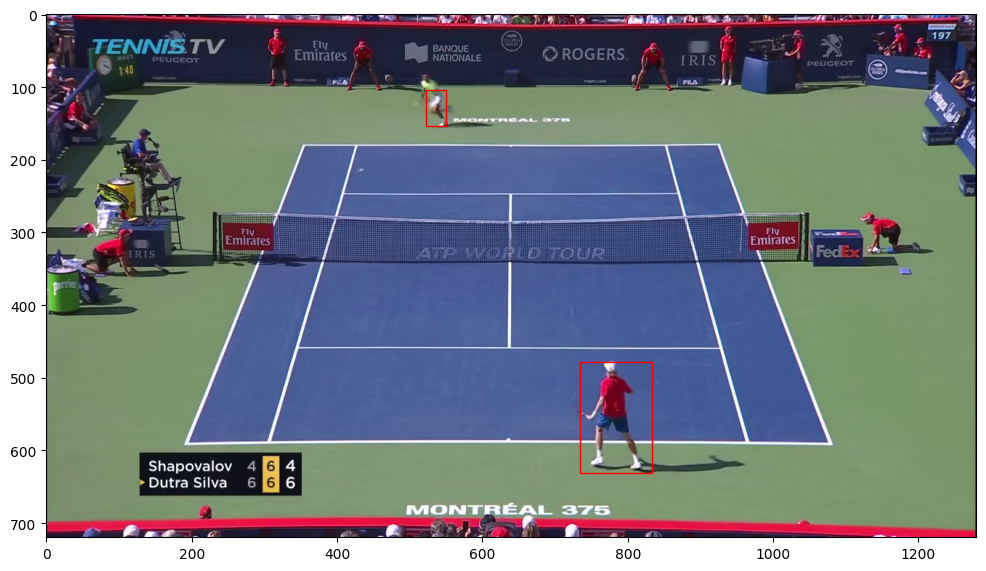

In [68]:
fig, ax = plt.subplots(1, figsize=(12, 8))
image_plot = ax.imshow(image_data)
boxes = []
distance_centre = pd.DataFrame(columns=['distance'])
image_centre = [list(image_data.size)[0]//2,list(image_data.size)[1]//2]
for result in results:
  for number,box in enumerate(result.boxes.xyxy.tolist()):
    distance_centre.loc[number,'distance'] = distance.euclidean(image_centre,np.array(box[:2]))
for result in results:
    for number,box in enumerate(result.boxes.xywh.tolist()):
      if number in distance_centre.sort_values(by='distance',ascending=True)[:2].index:
        ax.add_patch(patches.Rectangle((box[0] - box[2]/2, box[1] - box[3]/2), box[2], box[3], linewidth=1, edgecolor='r', facecolor='none'))
        boxes.append(box)
plt.show()

In [69]:
player_image_3 = image_data.crop((boxes[0][0]-boxes[0][2]/2,boxes[0][1]-boxes[0][3]/2,boxes[0][0]+boxes[0][2]/2,boxes[0][1]+boxes[0][3]/2))
player_image_4 = image_data.crop((boxes[1][0]-boxes[1][2]/2,boxes[1][1]-boxes[1][3]/2,boxes[1][0]+boxes[1][2]/2,boxes[1][1]+boxes[1][3]/2))

In [70]:
kmeans = KMeans(n_clusters=10,random_state=10)
kmeans.fit(np.array(player_image_3).reshape((-1, 3)))
colors_3 = kmeans.cluster_centers_
kmeans.fit(np.array(player_image_4).reshape((-1, 3)))
colors_4 = kmeans.cluster_centers_

In [71]:
boxes

[[784.0772094726562, 554.3424072265625, 99.23876953125, 152.18771362304688],
 [536.19580078125, 128.96759033203125, 28.441650390625, 49.98992919921875]]

In [72]:
distance.euclidean(colors_2.flatten(),colors_4.flatten())

445.7229088039487

In [73]:
distance.euclidean(colors_1.flatten(),colors_4.flatten())

562.8589729312481

In [74]:
distance.euclidean(colors_1.flatten(),colors_3.flatten())

528.7809175726372